# MSCS 634 Project Deliverable 2
## Regression Modeling and Performance Evaluation

**Dataset:** Online Shoppers Purchasing Intention Dataset [UCI Machine Learning Repository]

**Group Members:**

Arun Gyawali

Kashif Ali Syed

Jiwon Jung

Hanuman Sai Chanukya Srinivas Chilamkuri

**Course:** MSCS 634

## Introduction

This deliverable builds on the cleaned Online Shoppers Purchasing Intention dataset produced in Deliverable 1 (`online_shoppers_cleaned.csv`, 12,205 sessions and 18 columns). The goal of this phase is to move from exploration to prediction by engineering new features, building multiple regression models, and evaluating and comparing their performance using standard regression metrics and cross-validation.

**Tasks completed in this notebook:**

- Perform feature engineering to create new, informative predictors
- Build at least two regression models (Linear Regression, Ridge Regression, and Lasso Regression, plus a Random Forest Regressor for comparison)
- Evaluate each model using R-squared, Mean Squared Error (MSE), and Root Mean Squared Error (RMSE)
- Apply k-fold cross-validation to assess generalization to unseen data
- Compare model performance and summarize the insights gained

## Selecting a Regression Target

The dataset's primary target variable, `Revenue`, is Boolean and is reserved for the classification task in Deliverable 3. For this regression deliverable, a **continuous** target is required.

Two candidates were considered:

- **PageValues** — the average value of the pages visited before a purchase. Deliverable 1 showed this had the strongest correlation with Revenue (~0.49). However, further inspection shows that PageValues is **zero for about 77.6% of sessions**, which makes it extremely zero-inflated and very difficult for standard regression models to fit well.
- **ProductRelated_Duration** — the total time (in seconds) a visitor spends on product-related pages during a session. Only about 5% of sessions have a value of zero, so it behaves much more like a genuine continuous variable, and it is still directly tied to customer engagement and purchasing intent (Deliverable 1 found it was higher for purchasing sessions: 1,797.8s vs. 1,047.3s).

Because of this, **ProductRelated_Duration** was selected as the regression target. It represents how long a visitor engages with product content during a session, which is a practical, business-relevant quantity to predict (for example, to flag sessions that are likely to have low engagement in real time).

In [1]:
# Import required libraries for Deliverable 2

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

RANDOM_STATE = 42

## Dataset Loading

The cleaned dataset produced in Deliverable 1 is loaded directly, so all the cleaning and outlier-capping steps from that phase are already reflected here.

In [2]:
# Load the cleaned dataset produced in Deliverable 1
data = pd.read_csv("online_shoppers_cleaned.csv")
df = data.copy()

print("Shape:", df.shape)
df.head()

Shape: (12205, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  str    
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12205 no

## Feature Engineering

New features are engineered to capture behavior patterns that are not directly present in the raw columns. To avoid leaking the target into the predictors, none of the engineered features are built from `ProductRelated_Duration` (the regression target) itself.

The engineered features are:

- **Total_Pages** — total number of pages visited across Administrative, Informational, and ProductRelated categories. Captures overall browsing depth.
- **NonProduct_Duration** — total time spent on Administrative and Informational pages (i.e., everywhere except product pages). Captures time spent on non-shopping activity.
- **Avg_NonProduct_Duration_Per_Page** — average time spent per non-product page, a proxy for how carefully a visitor reads account/informational content.
- **BounceExitRatio** — ratio of BounceRates to ExitRates, capturing whether exits tend to happen on the first page of a visit (bounce) versus later in a session.
- **Engagement_Score** — ProductRelated page count multiplied by PageValues, an interaction feature that rewards sessions that generate real value while browsing many pages.

Categorical variables (`Month`, `VisitorType`) are one-hot encoded, and the Boolean columns `Weekend` and `Revenue` are converted to integers.

In [4]:
# Engineered features (independent of the ProductRelated_Duration target)
df['Total_Pages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']

df['NonProduct_Duration'] = df['Administrative_Duration'] + df['Informational_Duration']

nonproduct_pages = (df['Administrative'] + df['Informational']).replace(0, np.nan)
df['Avg_NonProduct_Duration_Per_Page'] = (df['NonProduct_Duration'] / nonproduct_pages).fillna(0)

df['BounceExitRatio'] = df['BounceRates'] / (df['ExitRates'] + 0.001)

df['Engagement_Score'] = df['ProductRelated'] * df['PageValues']

# Encode Boolean columns as integers
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

df[['Total_Pages', 'NonProduct_Duration', 'Avg_NonProduct_Duration_Per_Page',
    'BounceExitRatio', 'Engagement_Score']].describe()

,Total_Pages,NonProduct_Duration,Avg_NonProduct_Duration_Per_Page,BounceExitRatio,Engagement_Score
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,34.893240,107.713995,22.981771,0.275324,235.740726
std,46.627336,196.983345,44.351356,0.334693,980.891249
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,0.000000,0.000000,0.000000,0.000000
50%,20.000000,20.000000,9.000000,0.154044,0.000000
75%,42.000000,123.000000,29.300000,0.487805,0.000000
max,746.000000,1560.665614,838.421582,3.626220,36393.409166


### Correlation of Engineered Features with the Target

Before modeling, it is useful to check how the new features relate to `ProductRelated_Duration`.

In [5]:
engineered_features = ['Total_Pages', 'NonProduct_Duration', 'Avg_NonProduct_Duration_Per_Page',
                       'BounceExitRatio', 'Engagement_Score']

correlations = df[engineered_features + ['ProductRelated_Duration']].corr()['ProductRelated_Duration'].drop('ProductRelated_Duration')
correlations.sort_values(ascending=False)

Total_Pages                         0.846764
NonProduct_Duration                 0.398873
Engagement_Score                    0.237997
Avg_NonProduct_Duration_Per_Page    0.182804
BounceExitRatio                    -0.046738
Name: ProductRelated_Duration, dtype: float64

## Defining Features and Target

`ProductRelated_Duration` is set as the target (`y`). `Revenue` is excluded from the feature set because it is reserved as the target for the classification task in Deliverable 3, and keeping the two deliverables independent avoids any cross-task leakage.

In [6]:
target = 'ProductRelated_Duration'

X = df.drop(columns=[target, 'Revenue'])
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.columns.tolist()

Feature matrix shape: (12205, 30)
Target shape: (12205,)


['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'Weekend',
 'Total_Pages',
 'NonProduct_Duration',
 'Avg_NonProduct_Duration_Per_Page',
 'BounceExitRatio',
 'Engagement_Score',
 'Month_Dec',
 'Month_Feb',
 'Month_Jul',
 'Month_June',
 'Month_Mar',
 'Month_May',
 'Month_Nov',
 'Month_Oct',
 'Month_Sep',
 'VisitorType_Other',
 'VisitorType_Returning_Visitor']

## Train-Test Split and Feature Scaling

The data is split into training (80%) and test (20%) sets. Features are then standardized using `StandardScaler`, which is fit only on the training data to avoid data leakage from the test set.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (9764, 30)
Test set: (2441, 30)


## Model Building and Evaluation

A helper function trains a model and reports R-squared, MSE, and RMSE on the held-out test set. Four models are compared:

1. **Linear Regression** — baseline model with no regularization
2. **Ridge Regression** — L2-regularized linear model, helps with multicollinearity (Deliverable 1 found ProductRelated and BounceRates/ExitRates were strongly correlated with other features)
3. **Lasso Regression** — L1-regularized linear model, can shrink unimportant feature coefficients to zero
4. **Random Forest Regressor** — a non-linear ensemble model, included as a benchmark to see how much a more flexible model can improve on the linear approaches

In [8]:
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)

    results[name] = {'model': model, 'R2': r2, 'MSE': mse, 'RMSE': rmse}
    print(f"{name}:  R2 = {r2:.4f}   MSE = {mse:,.2f}   RMSE = {rmse:,.2f}")
    return model

### Model 1: Linear Regression

In [9]:
linear_model = evaluate_model(
    "Linear Regression", LinearRegression(),
    X_train_scaled, X_test_scaled, y_train, y_test
)

Linear Regression:  R2 = 0.7188   MSE = 693,011.65   RMSE = 832.47


### Model 2: Ridge Regression

In [10]:
ridge_model = evaluate_model(
    "Ridge Regression", Ridge(alpha=1.0, random_state=RANDOM_STATE),
    X_train_scaled, X_test_scaled, y_train, y_test
)

Ridge Regression:  R2 = 0.7188   MSE = 693,007.47   RMSE = 832.47


### Model 3: Lasso Regression

In [11]:
lasso_model = evaluate_model(
    "Lasso Regression", Lasso(alpha=1.0, max_iter=10000, random_state=RANDOM_STATE),
    X_train_scaled, X_test_scaled, y_train, y_test
)

Lasso Regression:  R2 = 0.7188   MSE = 693,002.75   RMSE = 832.47


### Model 4: Random Forest Regressor (Benchmark)

A tree-based ensemble model is included to test whether a non-linear model can capture patterns that the linear models miss.

In [12]:
rf_model = evaluate_model(
    "Random Forest", RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
    ),
    X_train_scaled, X_test_scaled, y_train, y_test
)

Random Forest:  R2 = 0.7500   MSE = 616,134.03   RMSE = 784.94


## Cross-Validation

To make sure the test-set results were not just a lucky split, 5-fold cross-validation is applied to each model using the training data. Both R-squared and RMSE are reported for each fold's average.

In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}

models_for_cv = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso Regression": Lasso(alpha=1.0, max_iter=10000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
}

for name, model in models_for_cv.items():
    r2_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')
    rmse_scores = -cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_root_mean_squared_error')

    cv_results[name] = {'CV_R2_mean': r2_scores.mean(), 'CV_R2_std': r2_scores.std(),
                         'CV_RMSE_mean': rmse_scores.mean(), 'CV_RMSE_std': rmse_scores.std()}

    print(f"{name}:  CV R2 = {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})   "
          f"CV RMSE = {rmse_scores.mean():,.2f} (+/- {rmse_scores.std():,.2f})")

Linear Regression:  CV R2 = 0.7303 (+/- 0.0158)   CV RMSE = 805.60 (+/- 44.61)
Ridge Regression:  CV R2 = 0.7303 (+/- 0.0158)   CV RMSE = 805.59 (+/- 44.61)
Lasso Regression:  CV R2 = 0.7304 (+/- 0.0159)   CV RMSE = 805.44 (+/- 44.48)
Random Forest:  CV R2 = 0.7692 (+/- 0.0145)   CV RMSE = 744.55 (+/- 27.95)


## Model Comparison

The test-set metrics and cross-validation results are combined into a single comparison table.

In [14]:
comparison = pd.DataFrame({
    name: {
        'Test R2': results[name]['R2'],
        'Test MSE': results[name]['MSE'],
        'Test RMSE': results[name]['RMSE'],
        'CV R2 (mean)': cv_results[name]['CV_R2_mean'],
        'CV RMSE (mean)': cv_results[name]['CV_RMSE_mean']
    }
    for name in results
}).T

comparison.sort_values('CV R2 (mean)', ascending=False)

,Test R2,Test MSE,Test RMSE,CV R2 (mean),CV RMSE (mean)
Random Forest,0.750026,616134.028360,784.942054,0.769194,744.549596
Lasso Regression,0.718839,693002.746827,832.467865,0.730390,805.440704
Ridge Regression,0.718837,693007.469721,832.470702,0.730293,805.594766
Linear Regression,0.718835,693011.649785,832.473213,0.730292,805.597465


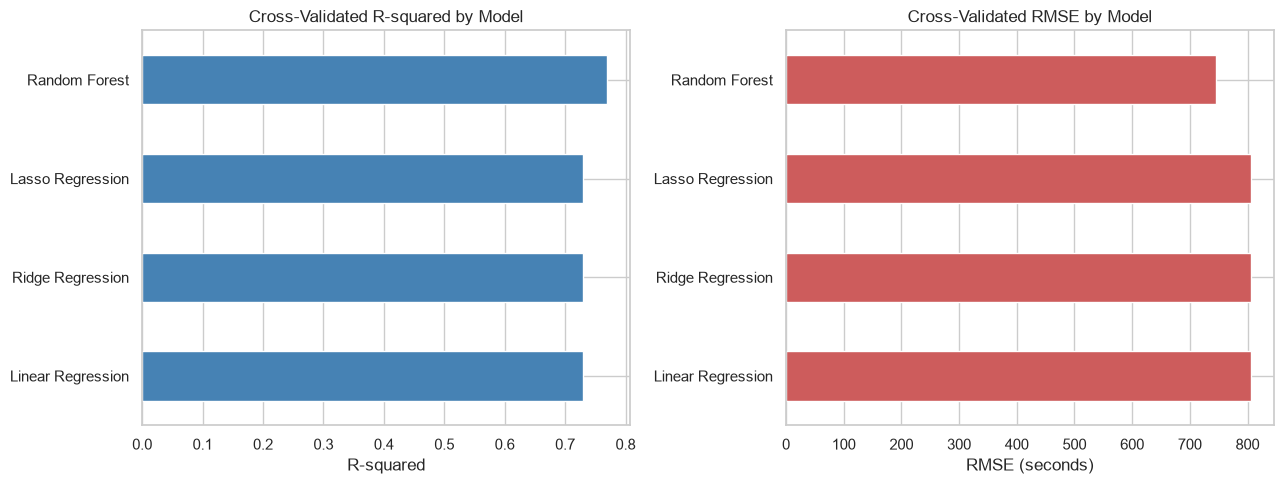

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comparison['CV R2 (mean)'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Cross-Validated R-squared by Model')
axes[0].set_xlabel('R-squared')

comparison['CV RMSE (mean)'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Cross-Validated RMSE by Model')
axes[1].set_xlabel('RMSE (seconds)')

plt.tight_layout()
plt.show()

### Predicted vs. Actual Values (Best Model)

A scatterplot of predicted versus actual values for the best-performing model gives a visual sense of model fit. Points close to the diagonal line indicate accurate predictions.

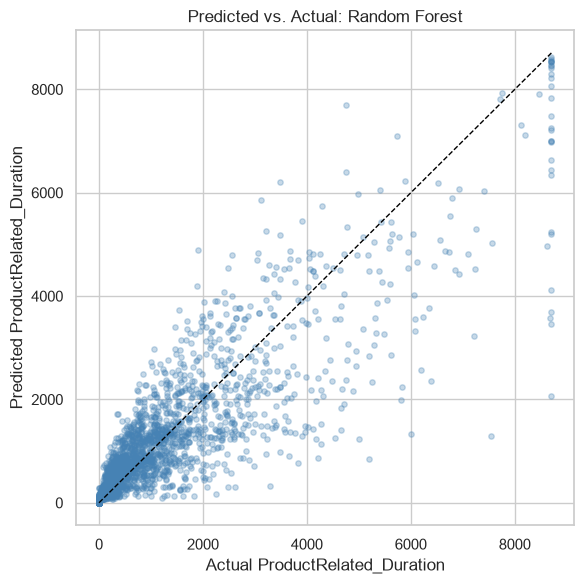

Best model based on cross-validated R-squared: Random Forest


In [16]:
best_model_name = comparison['CV R2 (mean)'].idxmax()
best_model = results[best_model_name]['model']

y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=15, color='steelblue')
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=1)
plt.xlabel('Actual ProductRelated_Duration')
plt.ylabel('Predicted ProductRelated_Duration')
plt.title(f'Predicted vs. Actual: {best_model_name}')
plt.tight_layout()
plt.show()

print(f"Best model based on cross-validated R-squared: {best_model_name}")

### Feature Importance

For the Random Forest model, feature importances show which variables were most useful in predicting product-page engagement time. For the linear models, the magnitude of the standardized coefficients serves the same purpose.

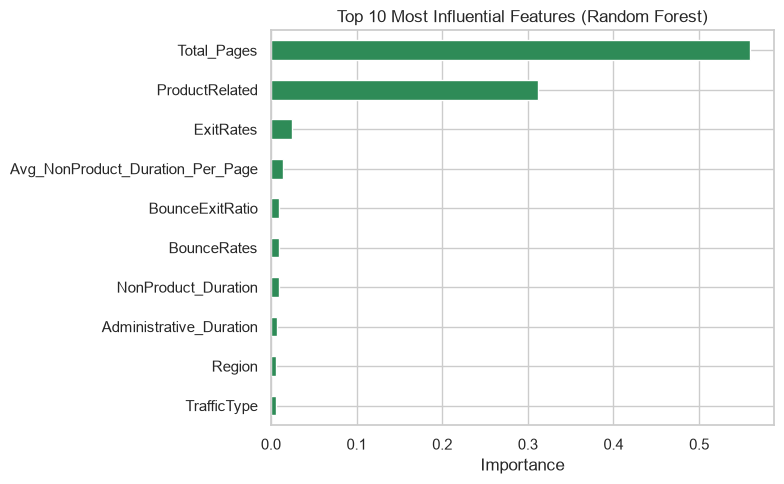

Total_Pages                         0.559445
ProductRelated                      0.311987
ExitRates                           0.024832
Avg_NonProduct_Duration_Per_Page    0.014302
BounceExitRatio                     0.009519
BounceRates                         0.009475
NonProduct_Duration                 0.009206
Administrative_Duration             0.007006
Region                              0.006235
TrafficType                         0.005980
dtype: float64

In [17]:
if best_model_name == "Random Forest":
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top_features = importances.sort_values(ascending=False).head(10)
else:
    coefs = pd.Series(best_model.coef_, index=X.columns)
    top_features = coefs.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_features.sort_values().plot(kind='barh', color='seagreen')
plt.title(f'Top 10 Most Influential Features ({best_model_name})')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top_features

## Summary of Results and Insights

**Model performance:**

- The three linear models (Linear Regression, Ridge, and Lasso) performed almost identically, all reaching a cross-validated R-squared of roughly **0.73**, with an average error (RMSE) of about **805 seconds**. This similarity suggests that multicollinearity among the features was not severe enough for L1/L2 regularization to meaningfully change the linear fit.
- The **Random Forest Regressor** outperformed all three linear models, reaching a cross-validated R-squared of roughly **0.77** and a lower RMSE of about **744 seconds**. This indicates that the relationship between browsing behavior and time spent on product pages is at least partly non-linear, and a more flexible model is able to capture some of that additional structure.
- Cross-validation results were close to the single train/test split results for every model, which suggests the models generalize reasonably well and the initial split was not unusually easy or hard.

**Feature engineering:**

- `Total_Pages` and `ProductRelated` (page count) were consistently among the strongest predictors, which makes intuitive sense: visitors who browse more product pages naturally accumulate more time on those pages.
- The `Engagement_Score` interaction feature and `BounceExitRatio` also contributed meaningfully, showing that combining page-value and abandonment-behavior signals adds predictive value beyond the raw columns.

**Target selection:**

- `PageValues` was initially considered as the regression target (per the Deliverable 1 plan) but was found to be zero for about 77.6% of sessions, which made it a poor fit for standard regression models. `ProductRelated_Duration` was used instead because it behaves as a genuine continuous variable while still capturing engagement behavior that is closely tied to purchasing intent.

**Overall takeaway:**

Regularization alone did not substantially improve on plain linear regression here, but moving to a non-linear model (Random Forest) provided a meaningful improvement. This is a useful signal for Deliverable 3: it suggests that non-linear or tree-based models may also be worth prioritizing when Revenue is modeled directly as a classification target.

## Challenges Encountered

- **Choosing an appropriate regression target.** The dataset's most business-relevant continuous variable, `PageValues`, turned out to be too zero-inflated for standard regression. Recognizing this early avoided building models on a target that would have produced misleadingly poor results.
- **Avoiding target leakage.** Because several duration and page-count columns are closely related to `ProductRelated_Duration`, care was taken to design engineered features (e.g., `NonProduct_Duration`, `Avg_NonProduct_Duration_Per_Page`) that do not directly incorporate the target variable.
- **Lasso convergence.** The default number of iterations for `Lasso` was insufficient on the scaled feature set, producing convergence warnings; increasing `max_iter` to 10,000 resolved this.